[1] "8.18"
[1] "All possible samples and their means:"
   A  B xbar
1  9  9  9.0
2 12  9 10.5
3 15  9 12.0
4  9 12 10.5
5 12 12 12.0
6 15 12 13.5
7  9 15 12.0
8 12 15 13.5
9 15 15 15.0
[1] "Sampling Distribution:"
  xbar     pxbar
1  9.0 0.1111111
2 10.5 0.2222222
3 12.0 0.3333333
4 13.5 0.2222222
5 15.0 0.1111111

PROVING THE THEOREMS
Mean of sampling distribution: 12 
Population mean:                    12 
Are they equal?                          TRUE 

Variance of sampling distribution:    3 
Population variance / 2 (sigma^2 / 2):   3 
Are they equal?                          TRUE 


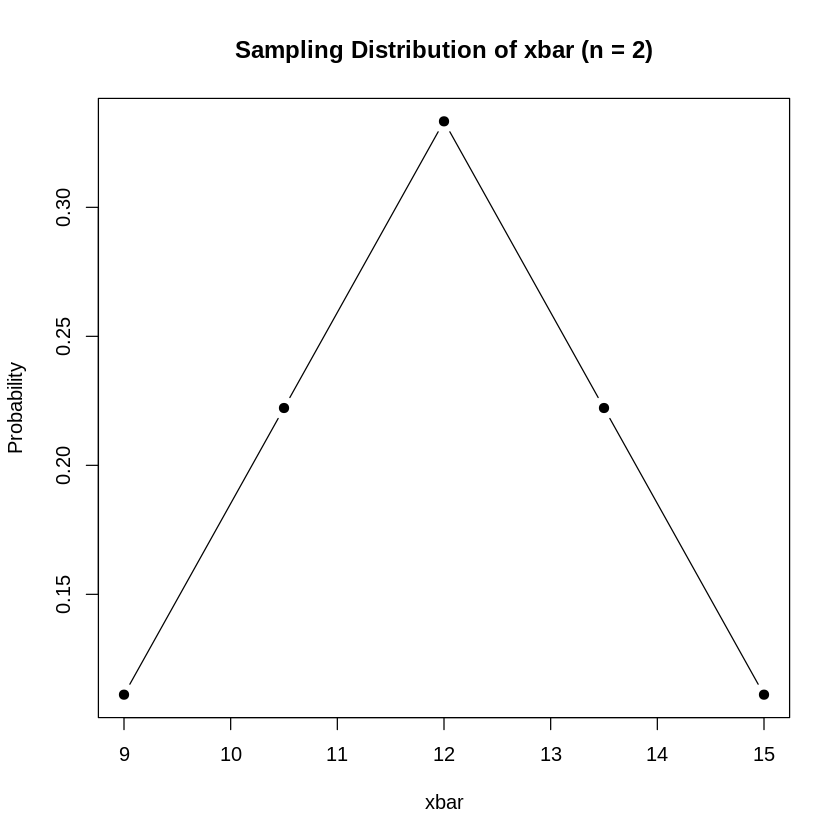

In [29]:
# 8.18
pop <- c(9, 12, 15)

samples <- expand.grid(A = pop, B = pop)
samples$xbar <- rowMeans(samples)

dist <- table(samples$xbar) / nrow(samples)
sd <- data.frame(
  xbar = as.numeric(names(dist)),
  pxbar = as.numeric(dist)
)

muxbar <- sum(sd$xbar * sd$pxbar)
varxbar <- sum((sd$xbar^2) * sd$pxbar) - muxbar^2

px <- 1/3
mupop <- sum(pop * px)
varpop <- sum((pop^2) * px) - mupop^2

print("8.18")
print("All possible samples and their means:")
print(samples)
print("Sampling Distribution:")
print(sd)

cat("\nPROVING THE THEOREMS\n")
cat("Mean of sampling distribution:", muxbar, "\n")
cat("Population mean:                   ", mupop, "\n")
cat("Are they equal?                         ", isTRUE(all.equal(muxbar, mupop)), "\n\n")

cat("Variance of sampling distribution:   ", varxbar, "\n")
cat("Population variance / 2 (sigma^2 / 2):  ", varpop / 2, "\n")
cat("Are they equal?                         ", isTRUE(all.equal(varxbar, varpop / 2)), "\n")

plot(
  sd$xbar,
  sd$pxbar,
  type = "b",
  pch = 19,
  xlab = "xbar",
  ylab = "Probability",
  main = "Sampling Distribution of xbar (n = 2)"
)

In [30]:
# 8.21
pop <- c(3, 7, 11, 15)
N <- length(pop)
n <- 2

mu <- mean(pop)

popvar <- sum((pop - mu)^2) / N
sigma <- sqrt(popvar)

samples <- expand.grid(v1 = pop, v2 = pop)
samples$xbar <- rowMeans(samples)

muxbar <- mean(samples$xbar)

sigmaxbar <- sqrt(sum((samples$xbar - muxbar)^2) / nrow(samples))

print("8.21")
cat("(a) Population Mean:", mu, "\n")
cat("(b) Population SD:", sigma, "\n")
cat("(c) Mean of Sampling Distribution:", muxbar, "\n")
cat("(d) SD of Sampling Dist:", sigmaxbar, "\n")

cat("\nVerification\n")
cat("Is muxbar == mu?", muxbar == mu, "\n")
cat("Is sigmaxbar == sigma/sqrt(n)?", isTRUE(all.equal(sigma_xbar, sigma / sqrt(n))), "\n")

[1] "8.21"
(a) Population Mean: 9 
(b) Population SD: 4.472136 
(c) Mean of Sampling Distribution: 9 
(d) SD of Sampling Dist: 3.162278 

Verification
Is muxbar == mu? TRUE 
Is sigmaxbar == sigma/sqrt(n)? TRUE 


In [31]:
#8.34
n <- 200
p <- 0.5
q <- 1 - p

sigmap <- sqrt((p * q) / n)
print("8.34")
cat("RESULTS: NORMAL APPROXIMATION\n")

phata <- 0.40
z_a <- (phata - p) / sigmap
proba <- pnorm(z_a)
cat("(a) P(< 40% boys):         ", round(proba, 4), "\n")

phatb1 <- 0.43
phatb2 <- 0.57
zb1 <- (phatb1 - p) / sigmap
zb2 <- (phatb2 - p) / sigmap
probb <- pnorm(zb2) - pnorm(zb1)
cat("(b) P(43% - 57% girls):    ", round(probb, 4), "\n")

phatc <- 0.54
zc <- (phatc - p) / sigmap
probc <- 1 - pnorm(zc)
cat("(c) P(> 54% boys):         ", round(probc, 4), "\n\n")


cat("VERIFICATION: EXACT BINOMIAL PROBABILITIES\n")
exacta <- pbinom(79, size = n, prob = p)

exactb <- pbinom(113, size = n, prob = p) - pbinom(86, size = n, prob = p)

exactc <- 1 - pbinom(108, size = n, prob = p)

cat("(a) Exact P(< 80 boys):    ", round(exacta, 4), "\n")
cat("(b) Exact P(86 < X < 114): ", round(exactb, 4), "\n")
cat("(c) Exact P(> 108 boys):   ", round(exactc, 4), "\n")

[1] "8.34"
RESULTS: NORMAL APPROXIMATION
(a) P(< 40% boys):          0.0023 
(b) P(43% - 57% girls):     0.9523 
(c) P(> 54% boys):          0.1289 

VERIFICATION: EXACT BINOMIAL PROBABILITIES
(a) Exact P(< 80 boys):     0.0018 
(b) Exact P(86 < X < 114):  0.944 
(c) Exact P(> 108 boys):    0.1146 


In [32]:
#8.49
x <- c(6, 9, 12, 15, 18)
px <- c(0.1, 0.2, 0.4, 0.2, 0.1)

mu <- sum(x * px)

sigma2 <- sum((x^2) * px) - mu^2

print("8.49")
cat("POPULATION PARAMETERS\n")
cat("Population Mean:", mu, "\n")
cat("Population Variance:", sigma2, "\n\n")

samples <- expand.grid(Draw1 = x, Draw2 = x)

samples$Sample_Mean <- rowMeans(samples)

problookup <- setNames(px, x)

pdraw1 <- problookup[as.character(samples$Draw1)]
pdraw2 <- problookup[as.character(samples$Draw2)]
samples$Probability <- pdraw1 * pdraw2

cat("25 POSSIBLE SAMPLES (n=2)\n")
print(samples, row.names = FALSE)

[1] "8.49"
POPULATION PARAMETERS
Population Mean: 12 
Population Variance: 10.8 

25 POSSIBLE SAMPLES (n=2)
 Draw1 Draw2 Sample_Mean Probability
     6     6         6.0        0.01
     9     6         7.5        0.02
    12     6         9.0        0.04
    15     6        10.5        0.02
    18     6        12.0        0.01
     6     9         7.5        0.02
     9     9         9.0        0.04
    12     9        10.5        0.08
    15     9        12.0        0.04
    18     9        13.5        0.02
     6    12         9.0        0.04
     9    12        10.5        0.08
    12    12        12.0        0.16
    15    12        13.5        0.08
    18    12        15.0        0.04
     6    15        10.5        0.02
     9    15        12.0        0.04
    12    15        13.5        0.08
    15    15        15.0        0.04
    18    15        16.5        0.02
     6    18        12.0        0.01
     9    18        13.5        0.02
    12    18        15.0        0.04
    